In [1]:
import pandas as pd

trails = pd.read_csv('cleaned_trails/cleaned_ca_trails.csv')
trails.head(3)


,ID,name,difficulty_rating,route_type,visitor_usage,avg_rating,area_name,city_name,features,activities,num_reviews,latitude,longitude,length_miles,elevation_gain_ft,steepness_ftmi,difficulty_category,area_category,url
0,10026910,Vernal and Nevada Falls via the Mist Trail,3,L,3.0,5.0,Yosemite National Park,Yosemite Valley,"['dogs-no', 'forest', 'partially-paved', 'rive...","['birding', 'hiking', 'nature-trips', 'walking']",1869,37.73495,-119.56619,6.4,2191.0001,342.343766,strenuous,National Park,https://www.alltrails.com/trail/us/california/...
1,10111800,Potato Chip Rock via Mt. Woodson Trail,5,O,4.0,4.5,Lake Poway Park,Poway,"['dogs-leash', 'lake', 'views', 'wild-flowers'...","['hiking', 'mountain-biking', 'nature-trips']",2756,33.00428,-117.01322,7.6,2106.0001,277.105276,strenuous,Park,https://www.alltrails.com/trail/us/california/...
2,10031492,Eaton Canyon Trail,3,O,4.0,4.0,Eaton Canyon Natural Area Park,Pasadena,"['cave', 'dogs-leash', 'forest', 'kids', 'rive...","['hiking', 'trail-running']",2084,34.17812,-118.09664,3.5,436.0000,124.571429,moderate,Park,https://www.alltrails.com/trail/us/california/...


# ---------------
### Minor clean up:



In [ ]:
# note: when pandas read the file it converted the lists of strings to strings of lists
# ex: "['birding', 'hiking', 'nature-trips', 'walking']"  - type string
display(trails.activities.head(2))
type(trails.activities.iloc[0])


In [ ]:
import ast
# convert 'activities' and 'features' columns to lists of strings
trails['activities'] = trails['activities'].apply(ast.literal_eval)
trails['features'] = trails['features'].apply(ast.literal_eval)


# ----------------

In [ ]:
trails.info()

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<br>
<br>
<br>
<br>

# ----
# num_reviews VS ave_rating:
- is there a relationship between the number of reivews and the average rating?
- Do more-reviewd trails tend to have higher ratings?
# ----

In [ ]:
display(trails[['num_reviews', 'avg_rating']].head())

sns.scatterplot(trails, x="num_reviews", y="avg_rating", alpha=0.2)
plt.xscale('log')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Average Rating')
plt.title('Number of Reviews vs. Average Rating (Log Scale)');

# note log scale hides values whose num_reviews == 0
# using log scale also helps to see the pattern since the data spans several orders of magnitude

## **Interpretation:**

There is no upward or downward slope - the number of reviews is a flat band between 4 and 5.

The number of reviews does not predict the rating but there is a filtering effect: bad trails never reach 100+ reviews.
  -  bad trails don't get popular enough to accumulate reviews?


In [ ]:
len(trails[trails.num_reviews == 0])  # note there are 278 unreviewed trails

<br>
<br>
<br>
<br>

# ----
# length_miles & elevation_gain_ft 
#   VS difficulty_rating
Is difficulty_rating essentially a function of length and elevation_gain?
# ----

In [ ]:
sns.relplot(trails, x="length_miles", y="elevation_gain_ft",
            hue="difficulty_rating",
            size="difficulty_rating",
            sizes=(25, 100),
            edgecolors='none',
            alpha=0.8)
plt.title("Difficulty Rating by Length and Elevation Gain ", pad=30);

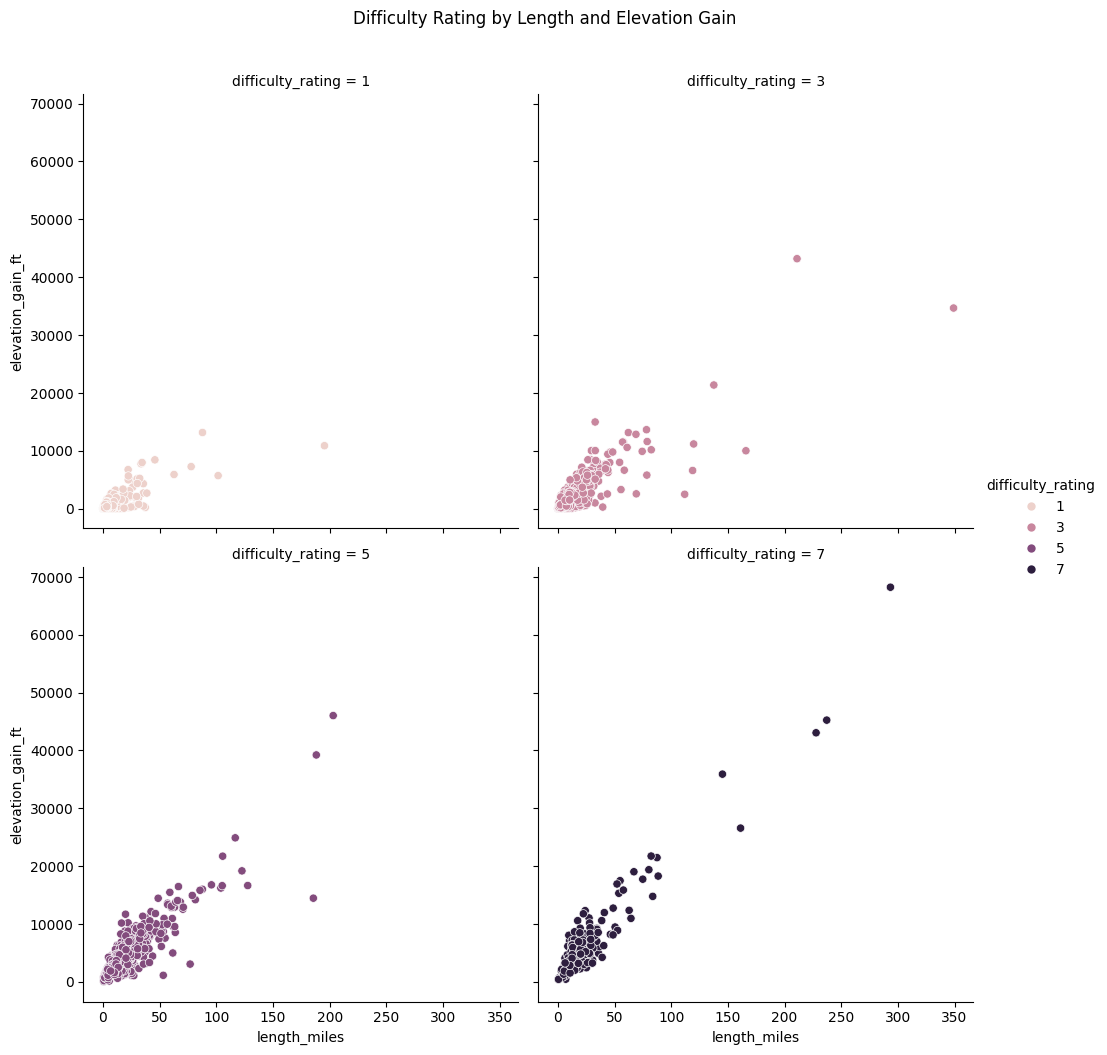

In [23]:
sns.relplot(trails, x="length_miles", y="elevation_gain_ft",
    hue="difficulty_rating",
    col="difficulty_rating",
    col_wrap=2,
    kind="scatter"
).fig.suptitle("Difficulty Rating by Length and Elevation Gain", y=1.05);

## **Interpretation:**


1. There is a cluster of points at low elevation and low miles for all difficulty levels...
   - there must be other factors influencing the difficulty level - terrain type, altitude, crowd-sourced bias?

2. As difficulty increases, the points spread out more, showing that longer and steeper trails tend to receive higher difficulty ratings, even though length and elevation alone don’t fully explain the categories.

3. The graph shows that elevation gain increases with trail length accross all difficulty levels
   - This is an obvious real‑world pattern, and it’s reassuring to see it show up clearly in the scraped dataset.

<br>

# -> Linear Regression model:


In [ ]:
from sklearn.linear_model import LinearRegression

X = trails[["length_miles", "elevation_gain_ft"]]
y = trails['difficulty_rating']

model = LinearRegression()
model.fit(X, y)

b_0 = model.intercept_
b_1, b_2 = model.coef_
print(f'baseline difficulty: {b_0}, \nlength coefficient: {b_1}, \nelevation gain coefficient: {b_2}')

interesting coefficients...
- length coefficient is negative (by a tiny number) which means that if we hold elevation gain constant, longer distances would be slightly less difficult..

- This dataset has reviews from many different people of different fitness levels, so one person who looks for a longer distance might rate the difficulty based mostly on elevation gain

- another note: High elevation gain feels harder when the trail is short because it’s steeper, so increasing length reduces steepness and lowers perceived difficulty.

Overall, difficulty is mostly driven by elevation gain, not length.

### **Cleaned dataset provides a new column: difficulty_category**

It uses Shenandoah's Hiking Difficulty formula
- See info here: https://www.nps.gov/shen/planyourvisit/how-to-determine-hiking-difficulty.htm

Shenandoah's Hiking difficulty is consistent with my data analysis which shows that elevation gain has a stronger effect on difficulty than distance does.

<br>
This column is based on elevation gain and distance instead of user‑submitted difficulty ratings, which can contain crowd‑sourced bias

<br>
<br>
<br>
<br>

# ----
# Difficulty category and Area category
- what does the difficulty distribution look like in each area type?
# ----

In [ ]:
trails[["difficulty_category", "area_category"]].head()

In [ ]:

difficulty_prop = {} # (area type) : (series of difficulty category proportions) 
area_counts = trails.area_category.value_counts()

for area_type in trails.area_category.dropna().unique():
    counts = trails[trails.area_category == area_type].difficulty_category.value_counts()
    difficulty_prop[area_type] = counts.map(lambda x : x/area_counts[area_type])



df_wide = pd.DataFrame(difficulty_prop).reset_index()
display(df_wide)

df_long = pd.melt(df_wide, id_vars=['difficulty_category'], var_name='Area Type', value_name='Proportion')



plt.figure(figsize=(15, 8))
sns.histplot(df_long, x="Area Type", weights="Proportion", hue='difficulty_category',
             multiple='stack',
             shrink=0.6,
             linewidth=.1)
plt.tight_layout()
plt.xlabel("Area", size=18, labelpad=25)
plt.xticks(rotation=45)
plt.ylabel("Proportion", size=18)
plt.title("Difficulty Distribution per Area Category", size=25, pad=25);


## **Interpretation:**

- National Parks and Forests show the highest proportions of very strenuous trails.

- Parks and Gardens show the highest proportions of easy trails.

- Most area categories contain a mix of difficulty levels, which suggests that difficulty is not tied to any single land‑type category.



<br>
<br>
<br>
<br>

# ----
# Steepnes vs Length
- How does steepness relate to trail length
# ----

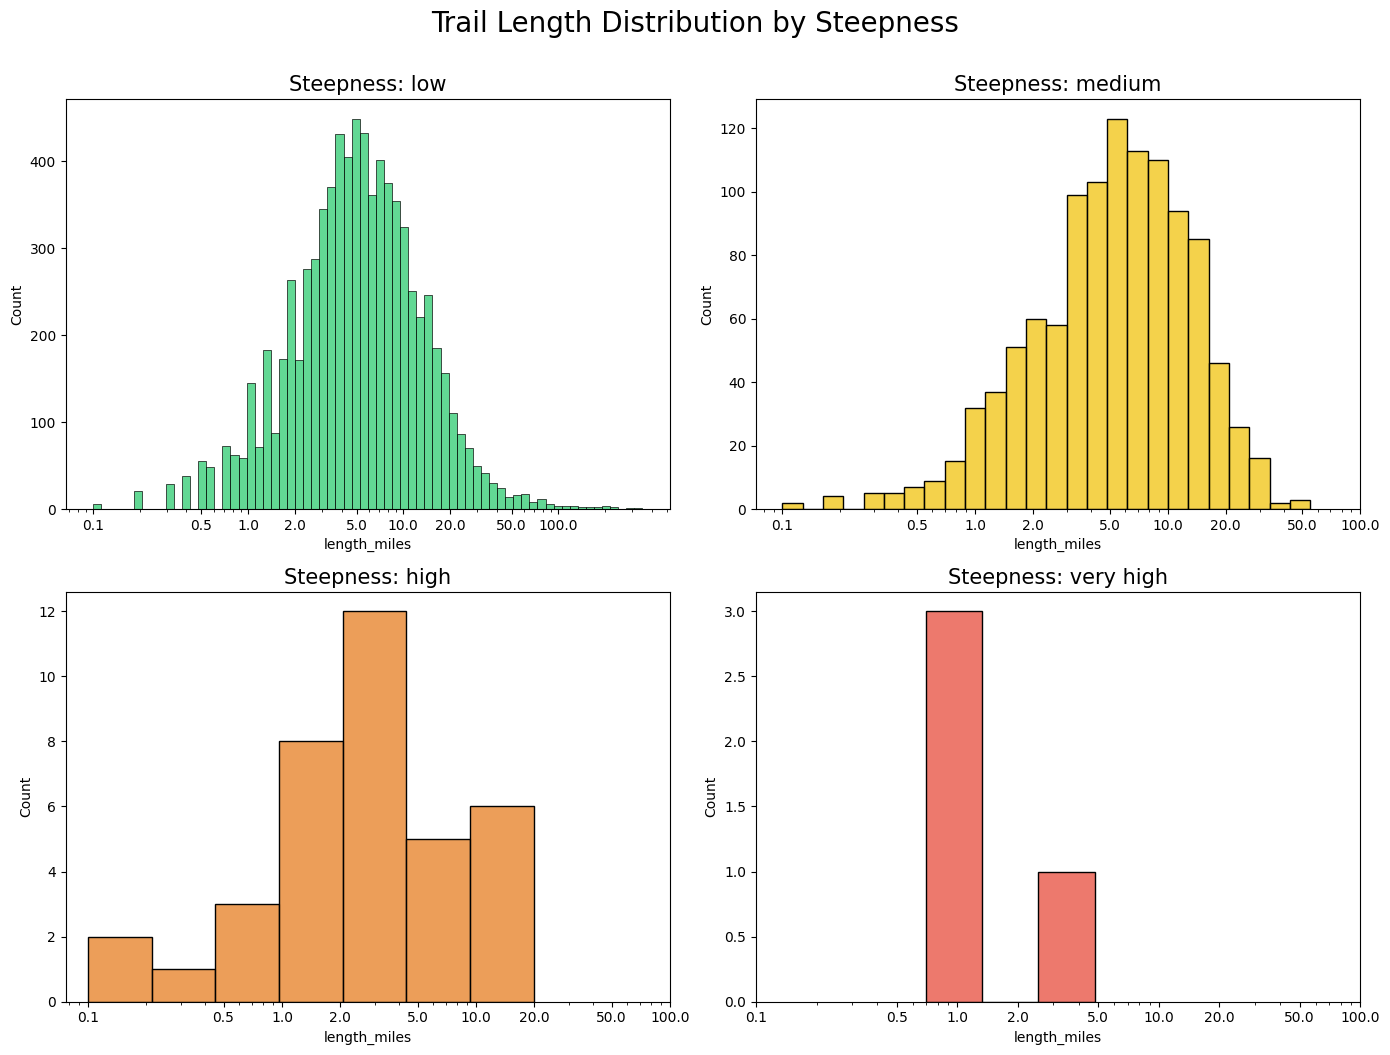

In [11]:
trails["steepness_bin"] = pd.cut(trails["steepness_ftmi"], bins=4, labels=["low", "medium", "high", "very high"])

fig, grid = plt.subplots(2, 2, figsize=(14, 10))   # grid is a 2x2 array
bins = ["low", "medium", "high", "very high"]
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]  # green, yellow, orange, red

for subplot, bin_label, color in zip(grid.flat, bins, colors):   # grid.flat flattens it into 1D array
    sns.histplot(
        data=trails[trails.steepness_bin == bin_label],
        x="length_miles",
        log_scale=True,
        ax=subplot,
        color=color
    )
    subplot.set_title(f"Steepness: {bin_label}", size=15)
    subplot.set_xticks([0.1, 0.5, 1, 2, 5, 10, 20, 50, 100])
    subplot.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
fig.suptitle("Trail Length Distribution by Steepness", y=1.05, size=20)
plt.show()


## **Interpretation:**
As steepness increases, trail length becomes shorter and less variable, while low‑steepness trails has a wide range of trail lengths, including very long ones.


<br>
<br>
<br>
<br>

# ----
# visitor_usage VS num_reviews
is there a correlation there?
# ----


In [ ]:
sns.barplot(trails, x="visitor_usage", y="num_reviews")
plt.title("Trail Visitor Usage and Review Counts");

## **Interpretation:**

Yes, there is a clear positive relationship.

More visitors -> more opportunities for people to leave reviews.

<br>
<br>
<br>
<br>

# ----
# activity_names and feature_names
# ----

In [ ]:
activites_counts = trails.activities.explode().value_counts()
lg_cnts = activites_counts[activites_counts >= 500]   # if we included all counts, it wouldn't fit on chart
sm_cnts = activites_counts[activites_counts < 500]
activites_counts = pd.concat([lg_cnts, pd.Series({"Other": sm_cnts.sum()})])

features_counts = trails.features.explode().value_counts()
lg_cnts = features_counts[features_counts >= 600]
sm_cnts = features_counts[features_counts < 600]
features_counts = pd.concat([lg_cnts, pd.Series({"Other": sm_cnts.sum()})])

In [ ]:
activites_counts.plot.pie().set_title("Activity Proportions", pad=15);


In [ ]:
features_counts.plot.pie().set_title("Features Proportions", pad=15);

<br>
<br>
<br>
<br>

# -----
# Latitude & Longitude
- lets plot data on a geographical map
# -----

In [21]:
# Exports  trail map to trail_map.html (use 'start trail_map.html' in terminal to open)


import folium

trail_map = folium.Map(   # create map
    location=[trails.latitude.mean(), trails.longitude.mean()],
    zoom_start=8,
    tiles='CartoDB positron',
    min_zoom=6,
    max_bounds=True,)    

trail_map.fit_bounds([[32.5, -124.5], [42.0, -114.1]])  # california only bounds

for idx, row in trails.iterrows():    # plot each trail on map
    popup_html = f"""
    <div style="font-size:14px; line-height:1.4;">
    <b>{row['name']}</b><br>
    Length: {row['length_miles']} miles<br>
    Difficulty: {row['difficulty_category']}
    </div>
    """
    # ^ include lenght and difficutly when you click on point on map (Note: it doesnt realy work for me)
    folium.CircleMarker(    
        [row.latitude, row.longitude],
        radius=3,
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(trail_map)



import geopandas as gpd
counties = gpd.read_file("https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/california-counties.geojson")

ca_counties_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/california-counties.geojson"

folium.GeoJson(    # loads county boundary shapes
    ca_counties_url,
    name="Counties",
    style_function=lambda x: {                     # TO DO ??????
        "fillColor": "transparent",      # change to a non-transparent color if trail completed in boundary???
        "color": "black",
        "weight": 0.5,   #boarder thickness
    }
).add_to(trail_map)

# adding countyname to center of each county
for _, row in counties.iterrows():   # looping through each county shape
    folium.Marker(
        location=[row.geometry.centroid.y, row.geometry.centroid.x],
        icon=folium.DivIcon(
            html=f'<div style="font-size:11px; font-weight:bold; color:black;">{row["name"]}</div>'
        )
    ).add_to(trail_map)

trail_map.save("trail_map.html")
